# Team Research Bot — LangGraph Edition

This notebook reimplements the **Researcher → Writer → Fact-Checker → Editor** pipeline using **LangGraph**.

All code lives in this notebook only — no imports from the project modules.

**Prerequisites:** Set `OPENAI_API_KEY` in your `.env` file before running.

**Notebook sections:**
1. Imports and configuration
2. Pydantic schemas (inter-agent contracts)
3. Prompts
4. Source loader
5. LLM client (OpenAI structured JSON)
6. Agent functions
7. LangGraph state and nodes
8. Build and compile the graph
9. Run the pipeline
10. Inspect messages, final report, and trace

In [1]:
# Install LangGraph and dependencies (run once per environment)
%pip install -q langgraph langchain-core pydantic openai python-dotenv pandas

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.0.38 requires langchain-core<0.2.0,>=0.1.52, but you have langchain-core 1.6.2 which is incompatible.
langchain-community 0.0.38 requires langsmith<0.2.0,>=0.1.0, but you have langsmith 0.12.1 which is incompatible.
langchain-text-splitters 0.0.2 requires langchain-core<0.3,>=0.1.28, but you have langchain-core 1.6.2 which is incompatible.
langchain 0.1.16 requires langchain-core<0.2.0,>=0.1.42, but you have langchain-core 1.6.2 which is incompatible.
langchain 0.1.16 requires langsmith<0.2.0,>=0.1.17, but you have langsmith 0.12.1 which is incompatible.
langchain-openai 0.1.7 requires langchain-core<0.3,>=0.1.46, but you have langchain-core 1.6.2 which is incompatible.
langchain-openai 0.1.7 requires openai<2.0.0,>=1.24.0, but you have openai 2.46.0 which is incompatible.
langchain-classic 1

## 1. Imports and configuration

In [2]:
from __future__ import annotations

import json
import operator ## Used with Annotatted [ operator.add]
import os
from dataclasses import dataclass
from datetime import datetime, timezone
from enum import Enum
from pathlib import Path
from typing import Annotated, Literal, Optional, Any,TypeVar
from uuid import uuid4

import pandas as pd
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field, ConfigDict, ValidationError, field_validator

load_dotenv()

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SOURCE_DIR = DATA_DIR / "source_pack"
TRACE_DIR = PROJECT_ROOT / "traces"
TRACE_DIR.mkdir(exist_ok=True)
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = os.getenv("OPENAI_MODEL")
MAX_REVISIONS = 2 # Maximum number of revisions for the editor agent after the Fact-checker critique 

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is not set")

if not OPENAI_MODEL:
    raise ValueError("OPENAI_MODEL is not set")


print(f"Project root :{PROJECT_ROOT}")
print(f"Model: {OPENAI_MODEL}")
print(f"Max revisions: {MAX_REVISIONS}")



Project root :/Users/rajesh/Desktop/rajesh/Archive/teaching/BMGR_JUNE/research_project
Model: gpt-4o-mini
Max revisions: 2


## 2. Pydantic schemas (inter-agent contracts)

Each agent produces a **typed payload**. The next agent expects exact fields — this is the "API contract" between agents.

| Schema | Producer | Consumer |
|--------|----------|----------|
| `ResearchReport` | Researcher | Writer |
| `DraftReport` | Writer | Fact-Checker |
| `FactCheckReport` | Fact-Checker | Writer / Editor |
| `FinalReport` | Editor | User |
| `AgentMessage` | All agents | Trace / debugging |

In [ ]:
# ---------------------------------------------------------------------------
# Enums — identify who is talking and what kind of message it is
# ---------------------------------------------------------------------------

class AgentRole(str,Enum):
    """Named roles in the research team.

    Used in AgentMessage.sender and AgentMessage.receiver so every handoff
    records exactly which agent produced output and which agent should consume it.
    """
    ORCHESTRATOR = "orchestrator"
    RESEARCHER = "researcher"
    WRITER = "writer"
    FACT_CHECKER = "fact_checker"
    EDITOR = "editor"



class MessageType(str, Enum):
    """Categories of inter-agent messages for tracing and debugging.

    - TASK: work assignment (not heavily used here; nodes call agents directly)
    - RESULT: an agent finished its job and produced a payload
    - CRITIQUE: Fact-Checker feedback that may trigger a revision
    - FINAL: Editor deliverable ready for the user
    """

    TASK = "task"
    RESULT = "result"
    CRITIQUE = "critique"
    FINAL = "final"

#created | running | need_revision | completed
class Status(str, Enum):
    CREATED = "created"
    RUNNING = "running"
    NEED_REVISION = "need_revision"
    COMPLETED = "completed"


# ---------------------------------------------------------------------------
# Base model — all schemas inherit strict validation rules
# ---------------------------------------------------------------------------

class StrictBaseModel(BaseModel):
    """Base model that rejects unknown fields — enforces schema discipline.

    extra='forbid' means the LLM cannot add random keys; if it does, Pydantic
    raises an error and the LLM client can attempt a JSON repair call.
    """
    model_config = ConfigDict(extra="forbid", validate_assignment=True)


# ---------------------------------------------------------------------------
# Researcher output shapes
# ---------------------------------------------------------------------------

class EvidenceItem(StrictBaseModel):
    """One piece of evidence copied or summarized from a source document.

    Fields:
        source_id: Stable ID like SRC-001 — used for citations and fact-checking.
        title: Human-readable source name shown in the final report.
        snippet: Short quote or summary from the source (min 30 chars).
        relevance_score: 0.0–1.0 estimate of how relevant this evidence is.
    """

    source_id: str
    title: str
    snippet: str = Field(..., min_length=30)
    relevance_score: float = Field(..., ge=0, le=1)


class ResearchFinding(StrictBaseModel):
    """A single claim backed by one or more evidence items.

    The Researcher must attach evidence to every claim so the Fact-Checker
    can later verify the Writer did not invent facts.
    """

    claim: str = Field(..., min_length=20)
    evidence: list[EvidenceItem] = Field(..., min_length=1)
    confidence: float = Field(..., ge=0, le=1)
    limitations: str



class ResearchReport(StrictBaseModel):
    """Researcher output: evidence-backed findings passed to the Writer.

    This is the first structured payload in the pipeline. The Writer must
    stay within these findings and must not add unsupported claims.
    """

    topic: str
    findings: list[ResearchFinding] = Field(..., min_length=2)
    unresolved_questions: list[str] = Field(default_factory=list)
    overall_confidence: float = Field(..., ge=0, le=1)


# ---------------------------------------------------------------------------
# Writer output shapes
# ---------------------------------------------------------------------------

class DraftSection(StrictBaseModel):
    """One section of the Writer's draft report.

    claim_ids links each section back to indexes in ResearchReport.findings
    so the Fact-Checker knows which research claims support each paragraph.
    """

    heading: str
    content: str = Field(..., min_length=80)
    claim_ids: list[int]


class DraftReport(StrictBaseModel):
    """Writer output: readable draft passed to the Fact-Checker.

    source_ids_used lists every source cited in the draft — the Fact-Checker
    checks these IDs exist in the Researcher's evidence.
    """

    title: str
    executive_summary: str = Field(..., min_length=80)
    sections: list[DraftSection] = Field(..., min_length=2)
    risks_or_uncertainties: list[str] = Field(default_factory=list)
    source_ids_used: list[str] = Field(default_factory=list)


# ---------------------------------------------------------------------------
# Fact-Checker output shapes
# ---------------------------------------------------------------------------

class ClaimCheck(StrictBaseModel):
    """Fact-check verdict for one claim or section.

    verdict drives the revision loop:
    - supported → no change needed
    - partially_supported / unsupported → may set revision_required=True
    """

    claim: str
    verdict: Literal["supported", "partially_supported", "unsupported"]
    evidence_refs: list[str] = Field(default_factory=list)
    issue: str
    recommendation: str

class FactCheckReport(StrictBaseModel):
    """Fact-Checker output: critique passed to Writer (revision) or Editor (final).

    revision_required is the key flag LangGraph uses in route_after_fact_check()
    to decide whether to send the draft back to the Writer.
    """

    checks: list[ClaimCheck] = Field(..., min_length=1)
    summary: str
    revision_required: bool
    overall_reliability: float = Field(..., ge=0, le=1)




# ---------------------------------------------------------------------------
# Editor output shape
# ---------------------------------------------------------------------------

class FinalReport(StrictBaseModel):
    """Editor output: polished final answer returned to the user.

    This is the only payload meant for human consumption. It merges the draft
    with fact-check feedback and keeps caveats visible.
    """

    title: str
    final_answer: str = Field(..., min_length=150)
    key_takeaways: list[str] = Field(..., min_length=3)
    caveats: list[str] = Field(default_factory=list)
    references: list[str] = Field(default_factory=list)
    editor_notes: str




# ---------------------------------------------------------------------------
# Message envelope — wraps every inter-agent handoff for tracing
# ---------------------------------------------------------------------------

class AgentMessage(StrictBaseModel):
    """Serializable envelope wrapping every inter-agent handoff.

    Think of this as an API request log entry:
    who sent it, who receives it, what task was assigned, the payload, and
    how confident the sender is in the result.
    """
    trace_id: str
    sender: AgentRole
    receiver: AgentRole
    message_type: MessageType
    task: str
    payload: dict[str, Any]
    confidence: float = Field(..., ge=0, le=1)
    created_at: str = Field(default_factory=lambda: datetime.now(timezone.utc).isoformat())

    @field_validator("trace_id")
    @classmethod
    def trace_id_must_not_be_empty(cls, value: str) -> str:
        """Reject blank trace IDs — they break debugging and log correlation."""
        if not value.strip():
            raise ValueError("trace_id cannot be blank")
        return value


def new_trace_id(prefix: str = "trace") -> str:
    """Generate a short unique ID for tracing a single message or step.

    Example output: msg_a1b2c3d4

    Args:
        prefix: Label prefix (e.g. 'msg' for messages, 'trace' for steps).

    Returns:
        A unique string safe to use in JSON trace files.
    """
    return f"{prefix}_{uuid4().hex[:8]}"





In [4]:
def make_message(
    sender: AgentRole,
    receiver: AgentRole,
    message_type: MessageType,
    task: str,
    payload_model: BaseModel,
    confidence: float,
) -> AgentMessage:
    """Wrap a Pydantic payload in a standard AgentMessage envelope for the trace log.

    Called by every LangGraph node after an agent finishes. Converts the typed
    Pydantic object into a plain dict (payload) for JSON serialization.

    Args:
        sender: Agent that produced the output (e.g. RESEARCHER).
        receiver: Agent that should consume it next (e.g. WRITER).
        message_type: RESULT, CRITIQUE, or FINAL.
        task: Short instruction describing what the receiver should do.
        payload_model: Validated Pydantic report (ResearchReport, DraftReport, etc.).
        confidence: Sender's confidence score between 0.0 and 1.0.

    Returns:
        AgentMessage ready to append to GraphState.messages.
    """
    return AgentMessage(
    trace_id=new_trace_id("msg"),
    sender=sender,
    receiver=receiver,
    message_type=message_type,
    task=task,
    payload=payload_model.model_dump(),
    confidence=confidence,
)

print("Schemas loaded.")


Schemas loaded.


## 3. Prompts

Each agent has a **system prompt** defining its role and rules. The user prompt (built at runtime) includes the task data and JSON schema.

In [5]:
# System prompts define each agent's ROLE and RULES.
# User prompts (built at runtime) supply the actual data + JSON schema.

RESEARCHER_SYSTEM_PROMPT = """
You are the Researcher agent in a multi-agent research team.
Your job is to extract evidence-backed findings from the provided local source pack.

Rules:
- Use only the provided sources.
- Every finding must include at least one evidence item.
- Be honest about limitations.
- Return valid JSON that conforms exactly to the provided schema.
"""
WRITER_SYSTEM_PROMPT = """
You are the Writer agent in a multi-agent research team.
Your job is to turn structured research findings into a concise, readable draft.

Rules:
- Do not invent claims beyond the research report.
- Keep the draft clear for a mixed technical/business audience.
- Mark uncertainty where the evidence is incomplete.
- Return valid JSON that conforms exactly to the provided schema.
"""

FACT_CHECKER_SYSTEM_PROMPT = """
You are the Fact-Checker agent in a multi-agent research team.
Your job is to compare the draft against the research evidence.

Rules:
- Verify whether each major claim is supported by the Researcher output.
- Mark claims as supported, partially_supported, or unsupported.
- Recommend concrete revisions, not vague criticism.
- Return valid JSON that conforms exactly to the provided schema.
"""


EDITOR_SYSTEM_PROMPT = """
You are the Editor agent in a multi-agent research team.
Your job is to produce the final answer using the draft and fact-check report.

Rules:
- Remove or soften unsupported claims.
- Preserve useful nuance and caveats.
- Make the answer polished but evidence-grounded.
- Return valid JSON that conforms exactly to the provided schema.
"""




In [6]:
def schema_instruction(schema_json: str) -> str:
    """Build the 'return JSON matching this schema' suffix for user prompts.

    Every agent call appends this to the user prompt so the LLM knows the exact
    output shape Pydantic will validate against.

    Args:
        schema_json: JSON Schema string from model_json_schema().

    Returns:
        Instruction text telling the model to return only valid JSON.
    """
    return (
        "Return only JSON. Do not include markdown fences. "
        "The JSON must match this schema:\n"
        f"{schema_json}"
    )

## 4. Source loader

Loads markdown files from `data/source_pack/`. The Researcher reads these as its evidence base (no live web search).

In [7]:
@dataclass
class SourceDocument:
    """One source document from the local source pack."""
    source_id: str
    # file: str
    title: str
    path: Path
    text: str

def _extract_title(markdown_text: str, fallback: str) -> str:
    """Pull the first markdown H1 heading as the document title.

    Args:
        markdown_text: Full markdown file content.
        fallback: Title to use if no '# Heading' line is found.

    Returns:
        Extracted title or fallback (usually the filename).
    """
    for line in markdown_text.splitlines():
        if line.startswith("# "):
            return line.replace("# ", "").strip()
    return fallback



def load_source_pack(source_dir: str | Path = SOURCE_DIR) -> list[SourceDocument]:
    """Load all markdown sources from the local source pack directory.

    Reads source_index.json when present (stable IDs and titles). Otherwise
    auto-assigns SRC-001, SRC-002, ... from sorted .md filenames.

    Args:
        source_dir: Path to folder containing .md files and optional index.

    Returns:
        List of SourceDocument objects ready for the Researcher prompt.

    Raises:
        FileNotFoundError: If the directory or an indexed file is missing.
        ValueError: If no markdown files are found.
    """

    source_path = Path(source_dir)
    if not source_path.exists():
        raise FileNotFoundError(f"Source pack directory not found: {source_path}")

    index_path = source_path / "source_index.json"
    documents: list[SourceDocument] = []
    if index_path.exists():
        # Preferred path: use index for consistent IDs across runs
        index_rows = json.loads(index_path.read_text(encoding="utf-8"))
        for row in index_rows:
            path = source_path / row["file"]
            text = path.read_text(encoding="utf-8")
            documents.append(
                SourceDocument(
                    source_id=row["source_id"],
                    # file=row["file"],
                    title=_extract_title(text, path.stem.replace("_", " ").title()),
                    path=path,
                    text=text,
                )
            )
    else:
        for index, path in enumerate(sorted(source_path.glob("*.md")), start=1):
            text = path.read_text(encoding="utf-8")
            documents.append(
                SourceDocument(
                    source_id=f"SRC-{index:03d}",
                    title=_extract_title(text, path.stem.replace("_", " ").title()),
                    path=path,
                    text=text,
                )
            )
    if not documents:
        raise ValueError(f"No markdown sources found in {source_path}")
    return documents


    
        

In [8]:
source_documents = load_source_pack()

In [9]:
source_documents[1].source_id

'SRC-002'

In [10]:
source_documents[1].text

"# Responsible AI in Hiring Workflows\n\nA mid-size recruitment platform tested AI agents for resume screening, interview question generation, and candidate shortlisting. The first prototype created ranking explanations that sounded confident but did not consistently map to job requirements. Recruiters also found that the system sometimes overweighted polished writing style instead of evidence of capability.\n\nThe redesign separated the workflow into roles. One agent extracted job requirements, another mapped candidate evidence to those requirements, and a reviewer agent checked whether a recommendation cited concrete resume evidence. Shortlisting decisions were never made automatically. A human recruiter approved or rejected each recommendation.\n\nBias review became a recurring checkpoint. The team compared selection rates across demographic proxies where legally permitted, checked whether education prestige was being overused, and documented reasons when the model's recommendation 

In [11]:
def render_sources_for_prompt(documents: list[SourceDocument], max_chars_per_doc: int = 1800) -> str:
    """Format source documents into a text block for the Researcher LLM prompt.

    Each document is clipped to max_chars_per_doc to control token cost.
    The Researcher sees source_id, title, and text for every document.

    Args:
        documents: Loaded SourceDocument list from load_source_pack().
        max_chars_per_doc: Character limit per document in the prompt.

    Returns:
        Single string with documents separated by '---' dividers.
    """

    blocks = []
    for doc in documents:
        clipped_text = doc.text[:max_chars_per_doc]
        blocks.append(f"Source ID: {doc.source_id}\nTitle: {doc.title}\nText:\n{clipped_text}\n")
    return "\n---\n".join(blocks)

documents = load_source_pack()
print(f"Loaded {len(documents)} source documents:")
for doc in documents:
    print(f"  - {doc.source_id}: {doc.title}")

Loaded 4 source documents:
  - SRC-001: AI Agents in Customer Support Operations
  - SRC-002: Responsible AI in Hiring Workflows
  - SRC-003: Healthcare Administrative Agents
  - SRC-004: Multi-Agent Governance Patterns


In [12]:
from openai import OpenAI
T = TypeVar("T", bound=BaseModel)


class StructuredLLMClient:
    """Calls OpenAI and validates every response against a Pydantic schema.

    All four agents share one client instance. Every call:
    1. Sends system + user prompt with JSON mode enabled
    2. Parses the response as JSON
    3. Validates against the expected Pydantic model
    4. On validation failure, attempts one automatic repair call
    """
    def __init__(self, model_name: str | None = None) -> None:
        """Initialize the OpenAI client.

        Args:
            model_name: Model override. Defaults to OPENAI_MODEL from .env.

        Raises:
            ValueError: If OPENAI_API_KEY is not set.
        """
        self.model_name = model_name or OPENAI_MODEL
        self.api_key = OPENAI_API_KEY

        if not self.api_key:
            raise ValueError("OPENAI_API_KEY is required. Add it to .env.")

        self.client = OpenAI(api_key=self.api_key)
    def complete_json(
        self,
        system_prompt: str,
        user_prompt: str,
        response_schema: type[T],
        temperature: float = 0.2,
    ) -> T:
        """Send a prompt to OpenAI, parse JSON, and validate against response_schema.

            This is the single entry point used by run_researcher, run_writer,
            run_fact_checker, and run_editor.

            Args:
                system_prompt: Agent role and behavior rules (from prompts section).
                user_prompt: Task data — query, prior reports, and JSON schema.
                response_schema: Pydantic model class the response must match.
                temperature: Sampling temperature (0.2 = mostly deterministic).

            Returns:
                Validated Pydantic model instance (e.g. ResearchReport).

            Raises:
                ValidationError: If JSON repair also fails (rare with gpt-4o-mini).
            """
        response = self.client.chat.completions.create(
            model=self.model_name,
            temperature=temperature,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
        )
        raw_content = response.choices[0].message.content or "{}"

        try:
            return response_schema.model_validate_json(raw_content)
        except ValidationError as original_error:
            return self._repair_json(raw_content, response_schema, str(original_error))

    
    def _repair_json(
        self,
        raw_content: str,
        response_schema: type[T],
        original_error: str,
    ) -> T:
        """Second LLM call that fixes JSON which failed Pydantic validation.

        Sends the invalid output, the validation error, and the target schema
        back to the model with temperature=0 for a deterministic repair.

        Args:
            raw_content: Malformed JSON from the first call.
            response_schema: Pydantic model the output must match.
            original_error: ValidationError message from the first attempt.

        Returns:
            Repaired and validated Pydantic model instance.
        """
        repair_prompt = (
            "The previous output failed validation. Repair it to match the schema. "
            "Return only JSON.\n\n"
            f"Validation error:\n{original_error}\n\n"
            f"Target schema:\n{json.dumps(response_schema.model_json_schema(), indent=2)}\n\n"
            f"Invalid output:\n{raw_content}"
        )
        response = self.client.chat.completions.create(
            model=self.model_name,
            temperature=0,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": "You repair JSON to match schemas."},
                {"role": "user", "content": repair_prompt},
            ],
        )
        repaired_content = response.choices[0].message.content or "{}"
        return response_schema.model_validate_json(repaired_content)

llm_client = StructuredLLMClient()
print(f"LLM client ready (model={llm_client.model_name})")

LLM client ready (model=gpt-4o-mini)


# Agent function

Each run_* function builds a prompt, calls the LLM , and return a validated Pydantic object.

In [15]:
def run_researcher(query: str, docs: list[SourceDocument]) -> ResearchReport:
    """Researcher agent — extract evidence-backed findings from local sources.

    Responsibility: READ sources, EXTRACT claims with citations. Does NOT write
    polished prose — that is the Writer's job.

    Steps:
    1. Format all source documents into a prompt block
    2. Attach the ResearchReport JSON schema
    3. Call OpenAI and validate the response

    Args:
        query: User's research question (e.g. about AI in customer support).
        docs: Source documents loaded by load_source_pack().

    Returns:
        ResearchReport with findings, evidence items, and confidence scores.
    """
    sources_block = render_sources_for_prompt(docs)
    schema_json = json.dumps(ResearchReport.model_json_schema(), indent=2)

    user_prompt = (
        f"Research question:\n{query}\n\n"
        f"Local source pack:\n{sources_block}\n\n"
        f"{schema_instruction(schema_json)}"
    )

    return llm_client.complete_json(
        system_prompt=RESEARCHER_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        response_schema=ResearchReport,
    )

def run_writer(
    query: str,
    research_report: ResearchReport,
    fact_check_report: FactCheckReport,
) -> DraftReport:
    """Writer agent — turn structured research into a readable draft report.

    Responsibility: WRITE clear prose grounded in the ResearchReport.
    Must NOT invent claims beyond what the Researcher found.

    Two modes:
    - Initial draft: fact_check_report is None
    - Revision draft: fact_check_report contains critique to address

    Args:
        query: Original user question (for context and title).
        research_report: Evidence-backed findings from the Researcher.
        fact_check_report: Optional critique from Fact-Checker (revision pass).

    Returns:
        DraftReport with executive summary, sections, and source_ids_used.
    """
    schema_json = json.dumps(DraftReport.model_json_schema(), indent=2)
    research_json = json.dumps(research_report.model_dump(), indent=2)

    if fact_check_report is None:
        # Initial draft — nothing to revise yet.
        user_prompt = (
            f"Original question:\n{query}\n\n"
            f"Research report (Researcher output):\n{research_json}\n\n"
            "Write the first draft report grounded strictly in the findings above.\n\n"
            f"{schema_instruction(schema_json)}"
        )
    else:
        # Revision pass — must address every fact-checker critique.
        fact_check_json = json.dumps(fact_check_report.model_dump(), indent=2)
        user_prompt = (
            f"Original question:\n{query}\n\n"
            f"Research report (Researcher output):\n{research_json}\n\n"
            f"Fact-Checker critique of your previous draft:\n{fact_check_json}\n\n"
            "Revise the draft to address every 'unsupported' or 'partially_supported' "
            "claim above while staying grounded in the research report.\n\n"
            f"{schema_instruction(schema_json)}"
        )

    return llm_client.complete_json(
        system_prompt=WRITER_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        response_schema=DraftReport,
    )


def run_fact_checker(
    draft_report: DraftReport,
    research_report: ResearchReport,
) -> FactCheckReport:
    """Fact-Checker agent — verify every draft claim against research evidence.

    Responsibility: COMPARE draft claims to Researcher evidence. Acts like
    a critic in a Reflexion loop — may send work back to the Writer.

    Key output field: revision_required
    - True  → LangGraph routes back to writer_node
    - False → LangGraph proceeds to editor_node

    Args:
        draft_report: Writer's draft with sections and source_ids_used.
        research_report: Original evidence from the Researcher.

    Returns:
        FactCheckReport with per-claim verdicts and revision_required flag.
    """
    schema_json = json.dumps(FactCheckReport.model_json_schema(), indent=2)
    draft_json = json.dumps(draft_report.model_dump(), indent=2)
    research_json = json.dumps(research_report.model_dump(), indent=2)

    user_prompt = (
        f"Draft report to verify (Writer output):\n{draft_json}\n\n"
        f"Research report evidence to check against (Researcher output):\n{research_json}\n\n"
        "Check every claim in the draft against the research evidence. Set "
        "revision_required=True if any claim is 'partially_supported' or 'unsupported'.\n\n"
        f"{schema_instruction(schema_json)}"
    )

    return llm_client.complete_json(
        system_prompt=FACT_CHECKER_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        response_schema=FactCheckReport,
    )


def run_editor(
    draft_report: DraftReport,
    fact_check_report: FactCheckReport,
) -> FinalReport:
    """Editor agent — produce the polished final answer for the user.

    Responsibility: POLISH the draft while respecting fact-check feedback.
    Removes or softens unsupported claims; keeps caveats visible.

    Args:
        draft_report: Latest Writer draft (initial or revised).
        fact_check_report: Fact-Checker verdicts and recommendations.

    Returns:
        FinalReport — the only output meant for human consumption.
    """
    schema_json = json.dumps(FinalReport.model_json_schema(), indent=2)
    draft_json = json.dumps(draft_report.model_dump(), indent=2)
    fact_check_json = json.dumps(fact_check_report.model_dump(), indent=2)

    user_prompt = (
        f"Latest draft report (Writer output):\n{draft_json}\n\n"
        f"Fact-Checker report (verdicts and recommendations):\n{fact_check_json}\n\n"
        "Produce the final answer for the user: remove or soften any claim marked "
        "'unsupported', keep caveats from the fact-check visible, and preserve "
        "useful nuance from the draft.\n\n"
        f"{schema_instruction(schema_json)}"
    )

    return llm_client.complete_json(
        system_prompt=EDITOR_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        response_schema=FinalReport,
    )

## 7. LangGraph state and nodes

LangGraph uses a shared **GraphState** that each node reads and partially updates.

- `operator.add` on `messages` and `errors` means new items are **appended**, not replaced.
- `route_after_fact_check` implements the **revision loop**: Fact-Checker can send work back to Writer.

In [34]:
from typing import TypedDict

class GraphState(TypedDict):
    """Shared state object passed between every LangGraph node.

    Each node reads from this state and returns a PARTIAL update dict.
    LangGraph merges updates into the full state before calling the next node.

    Fields annotated with operator.add (messages, errors) are APPENDED,
    not overwritten — so the message log grows with every handoff.
    """
    run_id: str   # Unique ID for this pipeline run
    user_query: str  # Original question 
    documents: list[SourceDocument]  # Loaded source documents
    source_id_cunsulted: list[str]  # IDs of source documents consulted
    research_report: ResearchReport | None  # Researcher output
    draft_report: DraftReport | None  # Writer output
    fact_check_report: FactCheckReport | None  # Fact-Checker output
    final_report: FinalReport | None  # Editor output
    revision_count: int                  # How many Writer revisions have occurred
    max_revisions: int                   # Stop condition for the revision loop
    status: str #created | running | need_revision | completed
    messages: Annotated[list[AgentMessage], operator.add]  # All messages in the pipeline
    errors: Annotated[list[str], operator.add]  # All errors in the pipeline
    


In [35]:
#created | running | need_revision | completed
class Status(str, Enum):
    CREATED = "created"
    RUNNING = "running"
    NEED_REVISION = "need_revision"
    COMPLETED = "completed"


In [36]:
def researcher_node(state: GraphState) -> GraphState:
    """LangGraph node — first step in the pipeline.

    Calls run_researcher(), stores the ResearchReport in state, and logs
    an AgentMessage handoff to the Writer.

    Input from state: user_query, documents
    Output to state:  research_report, source_ids_consulted, messages, status
    """

    query = state["user_query"]
    docs = state["documents"]

    research = run_researcher(state["user_query"], state["documents"])
    # Collect every source_id referenced in the research findings


    source_ids = sorted(
        {evidence.source_id for finding in research.findings for evidence in finding.evidence}

    )
    message = make_message(
        sender=AgentRole.RESEARCHER,
        receiver=AgentRole.WRITER,
        message_type=MessageType.RESULT,
        task= "use these evidence-based findings to draft a research brief",
        payload_model= research,
        confidence=research.overall_confidence,
    )

    return {
        "research_report": research,
        "source_ids_consulted": source_ids,
        "messages": [message],
        "status": Status.RUNNING,


    }
        

def writer_node(state: GraphState) -> GraphState:
    """LangGraph node — draft or revise the research brief.

    Called twice when a revision is needed:
    1. First pass:  fact_check_report is None → initial draft
    2. Second pass: fact_check_report has critique → revised draft

    Detects revision by checking if draft_report already exists AND
    Fact-Checker set revision_required=True.

    Input from state: user_query, research_report, fact_check_report (optional)
    Output to state:  draft_report, messages, revision_count (if revising)
    """

    assert state["research_report"] is not None

    updates: dict[str, Any] = {}

    fact_check = state.get("fact_check_report")
    revision_count = state.get("revision_count", 0)
    # Revision pass: increment counter and mark status before calling Writer

    if (
        state.get("draft_report")
        and fact_check
        and fact_check.revision_required
        and revision_count < state["max_revisions"]
    ):
        updates["revision_count"] = revision_count + 1
        updates["status"] = "needs_revision"

    draft = run_writer(state["user_query"], state["research_report"], fact_check)

    message = make_message(
        sender=AgentRole.WRITER,
        receiver = AgentRole.FACT_CHECKER,
        message_type=MessageType.RESULT,

        task= "verify the draft report against the research evidence",
        payload_model= draft,
        confidence=0.78 if fact_check else 0.72,
    )
    updates.update({"draft_report": draft, "messages": [message]})

    return updates



def fact_checker_node(state: GraphState) -> dict[str, Any]:
    """LangGraph node — verify draft claims against research evidence.

    After this node runs, route_after_fact_check() decides the next step:
    back to Writer (revision) or forward to Editor (final polish).

    Input from state: draft_report, research_report
    Output to state:  fact_check_report, messages
    """
    assert state["draft_report"] is not None and state["research_report"] is not None

    fact_check = run_fact_checker(state["draft_report"], state["research_report"])

    # Receiver in the message hints at the likely next node (for trace readability)
    receiver = AgentRole.WRITER if fact_check.revision_required else AgentRole.EDITOR

    message = make_message(
        sender=AgentRole.FACT_CHECKER,
        receiver=receiver,
        message_type=MessageType.CRITIQUE,
        task="Revise the draft if needed; otherwise prepare final editing.",
        payload_model=fact_check,
        confidence=fact_check.overall_reliability,
    )
    return {"fact_check_report": fact_check, "messages": [message]}

def editor_node(state: GraphState) -> dict[str, Any]:
    """LangGraph node — final step, produces the user-facing answer.

    Combines the latest draft with fact-check feedback into a FinalReport.
    Sets status to 'completed' when done.

    Input from state: draft_report, fact_check_report
    Output to state:  final_report, messages, status='completed'
    """
    assert state["draft_report"] is not None and state["fact_check_report"] is not None

    final = run_editor(state["draft_report"], state["fact_check_report"])

    message = make_message(
        sender=AgentRole.EDITOR,
        receiver=AgentRole.ORCHESTRATOR,
        message_type=MessageType.FINAL,
        task="Return the final answer to the user.",
        payload_model=final,
        confidence=state["fact_check_report"].overall_reliability,
    )
    return {"final_report": final, "messages": [message], "status": "completed"}



def route_after_fact_check(state: GraphState) -> Literal["writer", "editor"]:
    """Conditional router — implements the revision loop stop/go logic.

    Called by LangGraph after fact_checker_node. Returns the NAME of the
    next node (not the node itself).

    Decision table:
    | revision_required | revision_count < max | Next node |
    |-------------------|----------------------|-----------|
    | True              | True                 | writer    |
    | True              | False (limit hit)    | editor    |
    | False             | any                  | editor    |

    Args:
        state: Current GraphState after fact-checking.

    Returns:
        'writer' to revise, or 'editor' to finalize.
    """
    fact_check = state.get("fact_check_report")
    if (
        fact_check
        and fact_check.revision_required
        and state.get("revision_count", 0) < state.get("max_revisions", 1)
    ):
        return "writer"
    return "editor"


## 8. Build and compile the graph

Wire nodes and edges into a LangGraph `StateGraph`. The dashed edge from Fact-Checker is the conditional revision loop.

In [37]:
# ---------------------------------------------------------------------------
# Build the LangGraph StateGraph
# ---------------------------------------------------------------------------
# Nodes  = agent steps (functions that read/update GraphState)
# Edges  = fixed transitions between nodes
# Conditional edges = dynamic routing based on state (revision loop)


workflow = StateGraph(GraphState)

# Register each agent wrapper as a named graph node
workflow.add_node("researcher", researcher_node)   
workflow.add_node("writer", writer_node)              # Step 2: draft (may repeat)
workflow.add_node("fact_checker", fact_checker_node)  # Step 3: verify
workflow.add_node("editor", editor_node)              # Step 4: polish

# Fixed edges — always run in this order on the happy path

workflow.add_edge(START, "researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", "fact_checker")
# Conditional edge — Fact-Checker may send work BACK to Writer

workflow.add_conditional_edges(
    "fact_checker",
    route_after_fact_check,
    {"writer": "writer", "editor": "editor"},
)
workflow.add_edge("editor", END)

# compile() turns the workflow definition into a runnable graph object
research_graph = workflow.compile()



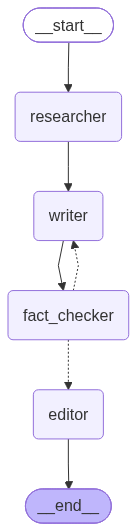

In [38]:
from IPython.display import Image, display

try:
    display(Image(research_graph.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

## 9. Run the pipeline

Invoke the compiled graph with an initial state. Each node runs in order, updating shared state.

In [39]:
# ---------------------------------------------------------------------------
# Run the full pipeline
# ---------------------------------------------------------------------------
# invoke() starts at START, runs each node in graph order, merges state
# updates, and stops at END when editor_node sets status='completed'.

USER_QUERY = (
    "What should an organization consider before using AI agents in customer support?"
)


# Initial state — all report fields are None; nodes fill them in order
initial_state: GraphState = {
    "run_id": f"run_{uuid4().hex[:10]}",
    "user_query": USER_QUERY,
    "documents": documents,
    "source_ids_consulted": [],
    "research_report": None,
    "draft_report": None,
    "fact_check_report": None,
    "final_report": None,
    "revision_count": 0,
    "max_revisions": MAX_REVISIONS,
    "status": "created",
    "messages": [],
    "errors": [],
}


final_state = research_graph.invoke(initial_state)


In [40]:
final_state

{'run_id': 'run_6013357f59',
 'user_query': 'What should an organization consider before using AI agents in customer support?',
 'documents': [SourceDocument(source_id='SRC-001', title='AI Agents in Customer Support Operations', path=PosixPath('/Users/rajesh/Desktop/rajesh/Archive/teaching/BMGR_JUNE/research_project/data/source_pack/ai_customer_support.md'), text='# AI Agents in Customer Support Operations\n\nA regional telecom company piloted an AI support assistant for billing, device troubleshooting, and plan-change questions. The system initially resolved simple questions quickly, but failed when customers mixed multiple intents in one message. The rollout improved only after the team added an escalation rule: unresolved or high-frustration conversations were routed to a human specialist.\n\nThe strongest operational gain came from triage rather than full automation. The AI assistant summarized the issue, collected account context, and suggested likely resolution paths. Human agent

In [41]:
print(f"Run ID: {final_state['run_id']}")
print(f"Status: {final_state['status']}")
print(f"Messages passed: {len(final_state['messages'])}")
print(f"Revisions used: {final_state['revision_count']}")

Run ID: run_6013357f59
Status: completed
Messages passed: 4
Revisions used: 0
